In [3]:
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
from zoneinfo import ZoneInfo

In [ ]:
# Configurações de treinamento
EPOCHS     = 5
BATCH      = 32
LR         = 1e-3
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Importando o dataset
path = kagglehub.dataset_download("dariobaumberger/combined-kaggle-mushrooms-dataset")
data_dir = f"{path}/images" if os.path.exists(f"{path}/images") else path

tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# Carregando todo dataset
full_ds = datasets.ImageFolder(data_dir, transform=tfm)

# Usar apenas 2% do dataset
subset_size = int(0.02 * len(full_ds))
remaining_size = len(full_ds) - subset_size
subset_ds, _ = random_split(full_ds, [subset_size, remaining_size])

# Separação do dataset: Treinamento (70%) e teste (30%) do subconjunto
train_size = int(0.7 * len(subset_ds))
test_size = len(subset_ds) - train_size
train_ds, test_ds = random_split(subset_ds, [train_size, test_size])

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH)

num_classes = len(full_ds.classes)
print(f"Total de Classes: {num_classes}\n\tTreino: {len(train_ds)} imagens\n\tTeste: {len(test_ds)} imagens (usando 2% do dataset original)")

Resuming download from 4120903680 bytes (3547204254 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/dariobaumberger/combined-kaggle-mushrooms-dataset/3.archive (4120903680/7668107934) bytes left.


100%|██████████| 7.14G/7.14G [01:22<00:00, 43.0MB/s]

Extracting files...


Total de Classes: 555
	Treino: 2735 imagens
	Teste: 1173 imagens (usando 2% do dataset original)


In [ ]:
# Modelo: MobileNetV2 pré-treinado
model = models.mobilenet_v2(weights="DEFAULT")

# Ajuste no modelo para o número real de espécies de cogumelos no dataset
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model = model.to(DEVICE)

# Treinamento
opt      = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn  = nn.CrossEntropyLoss()

print(f"Iniciando o treinamento: {datetime.now(ZoneInfo("America/Sao_Paulo")).strftime("%d/%m/%Y - %H:%M:%S")}")

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = correct = 0

    for X, y in train_dl:
        X, y = X.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out  = model(X)
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()

        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()

    acc = correct / len(train_ds) * 100
    print(f"Epoch {epoch}/{EPOCHS}  loss={total_loss/len(train_dl):.4f}  acc={acc:.1f}% \t[{datetime.now(ZoneInfo("America/Sao_Paulo")).strftime("%d/%m/%Y - %H:%M:%S")}]")

# Salvar o modelo
torch.save(model.state_dict(), "mushroom_species_model.pth")
print(f"\nModelo salvo em mushroom_species_model.pth em {datetime.now(ZoneInfo("America/Sao_Paulo")).strftime("%d/%m/%Y - %H:%M:%S")}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 108MB/s] 


Iniciando o treinamento: 08/06/2026 - 15:53:51
Epoch 1/5  loss=5.4003  acc=11.5% 	[08/06/2026 - 15:56:37]
Epoch 2/5  loss=3.6852  acc=26.1% 	[08/06/2026 - 15:59:16]
Epoch 3/5  loss=2.2026  acc=50.9% 	[08/06/2026 - 16:01:58]
Epoch 4/5  loss=1.1367  acc=75.2% 	[08/06/2026 - 16:04:39]
Epoch 5/5  loss=0.4434  acc=91.5% 	[08/06/2026 - 16:07:19]

Modelo salvo em mushroom_species_model.pth em 08/06/2026 - 16:07:19


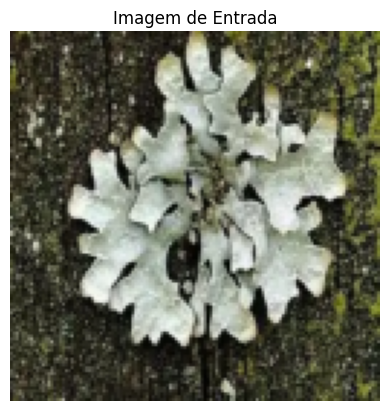

Predição Principal: Parmelia sulcata (63.4%)

Outras possibilidades (Top 3):
  1º - Parmelia sulcata: 63.4%
  2º - Hypogymnia physodes: 15.4%
  3º - Lobaria pulmonaria: 3.1%


In [ ]:
# Caminho da imagem
image_path = "cogumelo_teste.webp"

# Carregar os pesos do modelo treinado
model.load_state_dict(torch.load("mushroom_species_model.pth", map_location=DEVICE))
model.eval()

# 2. Transformar a imagem
img_pil = Image.open(image_path).convert("RGB")
img_tensor = tfm(img_pil).unsqueeze(0).to(DEVICE)

# Desnormalizar a imagem
img_display = img_tensor.squeeze(0).cpu().numpy()
img_display = img_display * 0.5 + 0.5
img_display = np.transpose(img_display, (1, 2, 0))
img_display = np.clip(img_display, 0, 1)

plt.imshow(img_display)
plt.axis('off')
plt.title('Imagem de Entrada')
plt.show()

# Fazer a predição
with torch.no_grad():
    saida = model(img_tensor)
    probs = torch.softmax(saida, dim=1)[0]

classes = full_ds.classes

# Trazer as 3 possibilidades com maior probabilidade (incluindo a principal)
top_probs, top_idxs = torch.topk(probs, 3)

print(f"Predição Principal: {classes[top_idxs[0]]} ({top_probs[0]*100:.1f}%)")

print("\nOutras possibilidades (Top 3):")
for i in range(3):
    idx = top_idxs[i].item()
    prob = top_probs[i].item() * 100
    print(f"  {i+1}º - {classes[idx]}: {prob:.1f}%")